# EXP5 - MVE Analysis

In [4]:
# Cell 1: imports and config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pymannkendall as mk
from pathlib import Path

from src.config import (
    PROCESSED_DATA_DIR,
    OUTPUT_DATA_DIR,
    OUTPUT_STATIC_ATTR,
    DATA_START_YEAR,
    DATA_END_YEAR,
    TRAIN_END_YEAR,
)

sns.set_theme(style='whitegrid', context='notebook')

# Analysis parameters
WINDOW = 15                       
WINDOWS_ROBUST = [10, 20]
N_MEMBERS = 10
N_BOOTSTRAP = 1000
RNG = np.random.default_rng(42)

# Input paths
TOPOGRAPH_LSTM = OUTPUT_DATA_DIR / 'topographic_lstm'
OBS_PATH = PROCESSED_DATA_DIR / 'combined_streamflow.csv'
STATIC_PATH = OUTPUT_STATIC_ATTR

# Output paths
MVE_RESULTS_DIR = OUTPUT_DATA_DIR / 'results_MVE'
FIG_DIR = MVE_RESULTS_DIR / 'figures'

# FIG_DIR.mkdir(parents=True, exist_ok=True)

## Math Foundation: decomposition and notation

**Setup**

- $y_t$ — observed flow at time $t$
- $f_m(x_t),\ m = 1,\dots,M,\ M = 10$ — frozen ensemble member predictions (point predictors)
- $\hat\mu_t = \frac{1}{M}\sum_{m=1}^{M} f_m(x_t)$ — ensemble mean
- $r_t = y_t - \hat\mu_t$ — residual
- $\hat b(x) = \mathbb{E}[\,r \mid x\,]$ — conditional bias (binned/smoothed mean residual, Part 1)

**Law of total variance** (the quantity being decomposed)

$$
\underbrace{\mathrm{Var}(y \mid x)}_{\text{total}}
= \underbrace{\mathbb{E}_{\theta}\!\big[\mathrm{Var}(y \mid x, \theta)\big]}_{\text{aleatoric},\ \sigma_a^2(x)}
+ \underbrace{\mathrm{Var}_{\theta}\!\big[\mathbb{E}(y \mid x, \theta)\big]}_{\text{epistemic},\ \sigma_e^2(x)}
$$

**Empirical estimators (point-predictor ensemble)**

Epistemic — between-member variance, available pointwise:

$$
\hat\sigma_e^2(x_t) = \frac{1}{M-1}\sum_{m=1}^{M}\big(f_m(x_t) - \hat\mu_t\big)^2
$$

Residual variance about the ensemble mean — the directly measurable quantity:

$$
T(x) = \mathrm{Var}\big[\,y - \hat\mu \mid x\,\big]
= \underbrace{\mathbb{E}[\,r^2 \mid x\,]}_{\mathrm{MSR}(x)} - \hat b(x)^2
= \sigma_a^2(x) + \frac{\sigma_e^2(x)}{M}
$$

estimated by binning/smoothing over similar $x$ (flow percentile or regime). The $\sigma_e^2/M$ leaks in because averaging $M$ members shrinks the model-uncertainty in $\hat\mu$ by $\sim 1/M$.

Aleatoric — the head's target — nets that piece back out:

$$
\hat\sigma_a^2(x) = T(x) - \frac{\hat\sigma_e^2(x)}{M}
$$

Total predictive variance (fresh prediction, full model uncertainty restored):

$$
\hat\sigma_{\text{tot}}^2(x) = \hat\sigma_a^2(x) + \hat\sigma_e^2(x) = T(x) + \frac{M-1}{M}\,\hat\sigma_e^2(x)
$$

Variance head (next stage):

$$
\hat\sigma_{\text{head}}^2(x_t) \approx \sigma_a^2(x_t)
$$

a smooth pointwise function fit to the empirical $\hat\sigma_a^2$.

**Notes**

1. **MSR is a second moment, not a variance.** $\mathrm{MSR}(x) = T(x) + b(x)^2$ (residual variance $+$ squared bias), so the Part 1 gate must net out $b^2$ before $T$ reads as spread — otherwise high-flow peak bias enters as fake noise. Where $\hat b(x) \approx 0$, $T(x) \approx \widehat{\mathrm{MSR}}(x)$. ($\mathrm{MSR}$ here uses $n$ in the denominator; an $n-p$ penalty would scale it but not change the decomposition.)
2. **Subtract $\sigma_e^2/M$, not $\sigma_e^2$.** The residual about $\hat\mu$ already contains only $\sigma_e^2/M$ of epistemic, so $\sigma_a^2 = T - \sigma_e^2/M$; the *reported* total adds the full $\sigma_e^2$ back. The $1/M$ is the whole reconciliation. Members are positively correlated, so true $\mathrm{Var}(\hat\mu)\in[\sigma_e^2/M,\ \sigma_e^2]$ — subtracting $\sigma_e^2/M$ is the conservative (largest-$\sigma_a^2$) edge, $\sigma_e^2$ the other, hence $T-\sigma_e^2 \le \sigma_a^2 \le T-\sigma_e^2/M$. *Cross-check:* per-member residual variance estimates $\sigma_a^2+\sigma_e^2$, the ensemble-mean version estimates $\sigma_a^2+\sigma_e^2/M$; their gap is $\tfrac{M-1}{M}\sigma_e^2$.
3. **Pointwise vs conditional.** $\hat\sigma_e^2$ exists at every $t$ (all $M$ members are present); $T$ and $\hat\sigma_a^2$ need many residuals, so they are binned/windowed, not per-timestep. This is why epistemic anchors the AR / heat-dome events pointwise while aleatoric-at-events waits for the head.
4. **Point predictors, so the head is necessary.** Members emit no per-member variance, so the LTV aleatoric term $\mathbb{E}_\theta[\mathrm{Var}(y\mid x,\theta)]$ is empty: the ensemble gives $\hat\sigma_e^2$ directly but cannot give $\sigma_a^2$, which is recovered from residuals here ($T - \hat\sigma_e^2/M$) and modelled by the head next.
5. **Conventions.** Use $M-1$ (ten members is a small sample); define $y, \hat\mu, r$ in the Part 1 transform space, and transform back explicitly if reporting native-flow variance, since the split is not invariant to the log/NSE\* mapping.

## Part 1 - Mean/residuals analysis from Frozen Mean head

Notes about this analysis:

We want to compare the ensemble mean ($\hat\mu$) against the observed flow $y$. We then are hoping to extract $\hat\sigma$ from a variance head post-hoc. 

## Bias:
### Residuals vs Fitted plot: With a mean estimate line and spread band
Check heteroscedasticity of predictions.

### Binned bias and spread by flow percentile: mean residual with confidence interval per bin, and residual standard deviation per bin
Shows whether bias concentrates in the high- and low-flow tails and how spread scales with flow.

### Predicted vs observed scatter, linear and log panels, with the 1:1 line 
The cloud falling below 1:1 at the top end is peak under-prediction; the log panel exposes low-flow behavior the linear panel hides.

269 stations x 15706 days | 3,763,874 valid (station,day) residuals


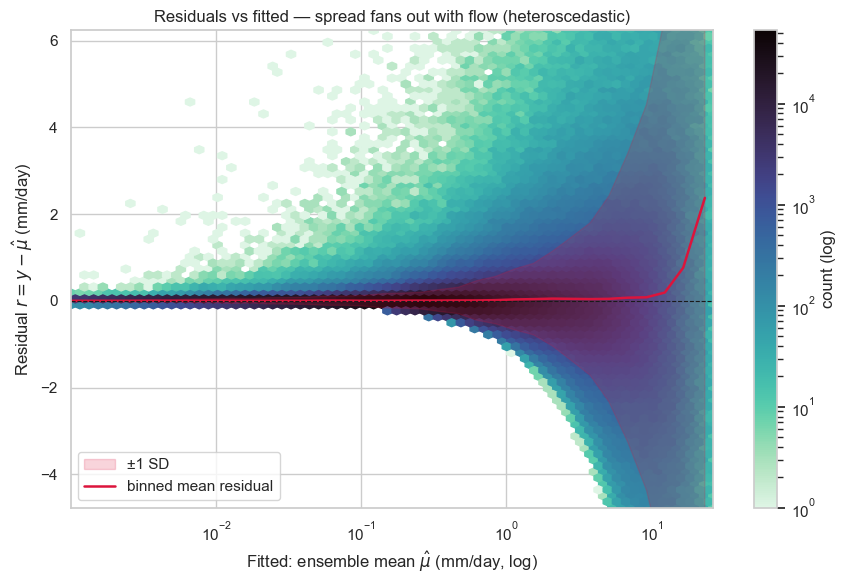

In [5]:
# Cell 6: Residuals vs fitted (heteroscedasticity check)
# --- Load once for all of Part 1 (no prior load cell; cells 7-8, 10-11 reuse these) ---
# Transform space = physical mm/day (sim CSVs are mm/day; obs is m3/s -> mm/day via
# 86.4/basin_area_km2, the documented 2026-05-19 convention). No log transform.

# Ensemble mean mu_hat = (1/M) sum_m f_m  (math cell, mu_hat)
_members = [
    pd.read_csv(TOPOGRAPH_LSTM / f'topographic_lstm_preds_member_{m}.csv',
                index_col=0, parse_dates=True)
    for m in range(N_MEMBERS)
]
assert all(d.index.equals(_members[0].index) for d in _members), 'member dates differ'
assert all(d.columns.equals(_members[0].columns) for d in _members), 'member stations differ'
mu = pd.DataFrame(np.stack([d.values for d in _members]).mean(axis=0),
                  index=_members[0].index, columns=_members[0].columns)

# Observed flow -> mm/day
obs_raw = pd.read_csv(OBS_PATH, index_col='Date', parse_dates=True)          # m3/s
area = pd.read_csv(STATIC_PATH).set_index('station_id')['basin_area_km2']     # km2

# Align on stations and dates common to all three
stations = sorted(set(obs_raw.columns) & set(mu.columns) & set(area.index))
dates = obs_raw.index.intersection(mu.index)
obs_mm = obs_raw.loc[dates, stations].mul(86.4 / area[stations], axis=1)      # mm/day
mu = mu.loc[dates, stations]
resid = obs_mm - mu                                                           # r = y - mu_hat
print(f'{len(stations)} stations x {len(dates)} days | '
      f'{np.isfinite(resid.values).sum():,} valid (station,day) residuals')

# Flatten and drop NaNs (pooled across all basins; see caveat below)
fit_flat = mu.values.ravel()
res_flat = resid.values.ravel()
obs_flat = obs_mm.values.ravel()
mask = np.isfinite(fit_flat) & np.isfinite(res_flat)

# CAVEAT: pooled across basins, so fitted flow mixes regime with basin scale (large
# basins -> larger mm/day). Cell 7 bins by *within-basin* percentile to isolate regime;
# here a LOG fitted-axis spreads the order-of-magnitude flow range so the spread fan is
# legible (the linear pooled view crushes 99% of points into the low-flow corner).

# Binned mean residual +/- 1 SD over LOG-spaced fitted bins (positive fitted only)
pos = mask & (fit_flat > 0)
fp, rp = fit_flat[pos], res_flat[pos]
edges = np.geomspace(np.quantile(fp, 0.005), np.quantile(fp, 0.999), 35)
bidx = np.clip(np.digitize(fp, edges[1:-1]), 0, len(edges) - 2)
ctr, m_r, sd_r = [], [], []
for b in range(len(edges) - 1):
    sel = bidx == b
    if sel.sum() < 50:
        continue
    ctr.append(np.median(fp[sel]))
    m_r.append(rp[sel].mean())
    sd_r.append(rp[sel].std())
ctr, m_r, sd_r = map(np.asarray, (ctr, m_r, sd_r))

fig, ax = plt.subplots(figsize=(9, 6))
xlim = (np.quantile(fp, 0.005), np.quantile(fp, 0.999))
ylim = np.quantile(rp, [0.005, 0.995])
hb = ax.hexbin(fp, rp, xscale='log', gridsize=70, bins='log', cmap='mako_r', mincnt=1,
               extent=(np.log10(xlim[0]), np.log10(xlim[1]), ylim[0], ylim[1]))
ax.fill_between(ctr, m_r - sd_r, m_r + sd_r, color='crimson', alpha=0.18, label='±1 SD')
ax.plot(ctr, m_r, color='crimson', lw=1.8, label='binned mean residual')
ax.axhline(0, ls='--', c='k', lw=0.8)
ax.set(xscale='log', xlim=xlim, ylim=tuple(ylim),
       xlabel='Fitted: ensemble mean $\\hat\\mu$ (mm/day, log)',
       ylabel='Residual $r = y - \\hat\\mu$ (mm/day)',
       title='Residuals vs fitted — spread fans out with flow (heteroscedastic)')
fig.colorbar(hb, ax=ax, label='count (log)')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()


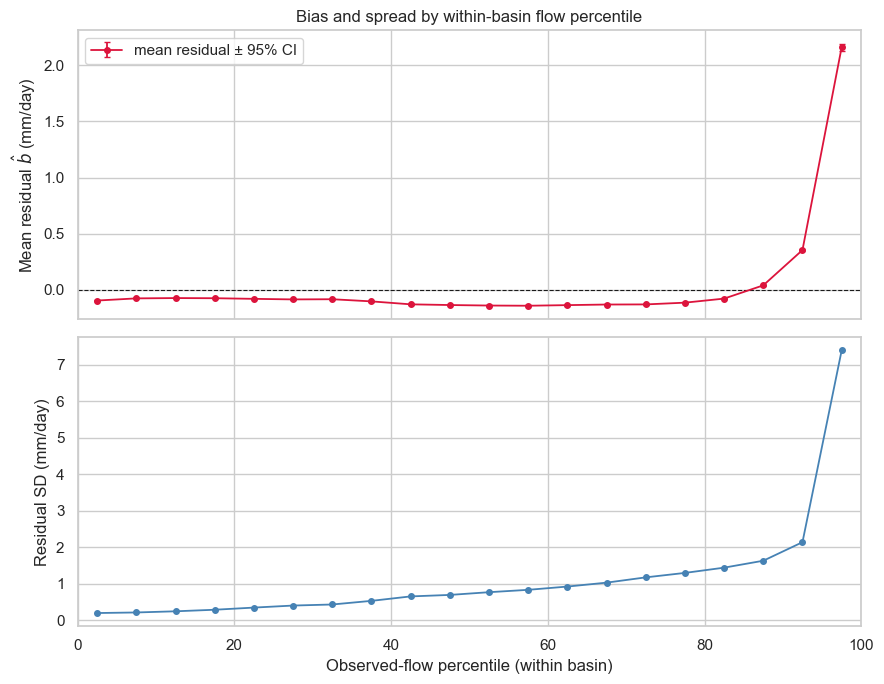

In [6]:
# Cell 7: Binned bias and spread by flow percentile
# Bin by WITHIN-BASIN observed-flow percentile (rank pct per station), so a bin is a
# flow *regime* ("each basin's top 5%"), not a basin-size artifact (cf. Cell 6 caveat).
pct = obs_mm.rank(pct=True)                       # per-station percentile across time
pct_flat = pct.values.ravel()
m2 = mask & np.isfinite(pct_flat)

NB = 20
bidx = np.clip((pct_flat[m2] * NB).astype(int), 0, NB - 1)
r = res_flat[m2]
centers = (np.arange(NB) + 0.5) / NB * 100        # bin center as percentile
mean_r = np.array([r[bidx == b].mean() for b in range(NB)])
std_r  = np.array([r[bidx == b].std()  for b in range(NB)])
n_b    = np.array([(bidx == b).sum()   for b in range(NB)])
ci = 1.96 * std_r / np.sqrt(n_b)                  # 95% CI on the bin mean

# CAVEAT: this CI assumes iid residuals. They are autocorrelated (see ACF cell) and
# spatially correlated across basins, so effective n << n_b and the CI is anti-
# conservative (here also visually tiny given n_b ~ 1e5). Read it as indicative, not
# calibrated; the std_r panel below is the substantive "how spread scales with flow".

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax1.axhline(0, ls='--', c='k', lw=0.8)
ax1.errorbar(centers, mean_r, yerr=ci, fmt='o-', color='crimson', ms=4,
             capsize=2, lw=1.3, label='mean residual ± 95% CI')
ax1.set(ylabel='Mean residual $\\hat b$ (mm/day)',
        title='Bias and spread by within-basin flow percentile')
ax1.legend(loc='best')

ax2.plot(centers, std_r, 'o-', color='steelblue', ms=4, lw=1.3)
ax2.set(xlabel='Observed-flow percentile (within basin)',
        ylabel='Residual SD (mm/day)', xlim=(0, 100))
plt.tight_layout()
plt.show()


Predicted <= 0 (dropped from log panel): 33,708 (0.90% of valid pairs)


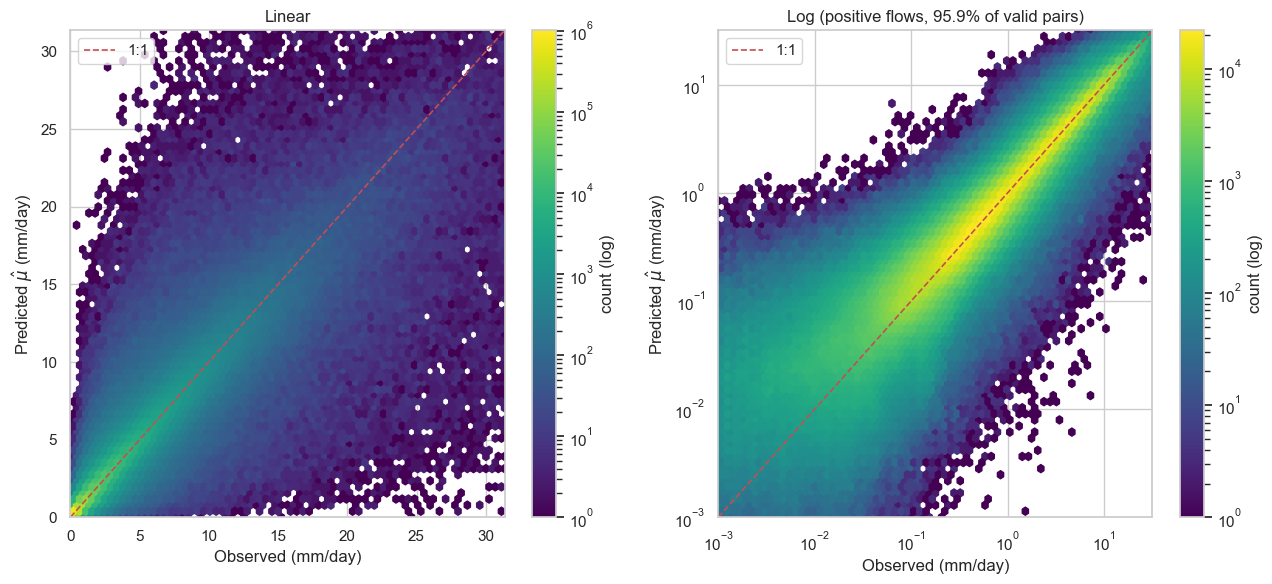

In [7]:
# Cell 8: Predicted vs observed scatter (linear + log), with 1:1 line
# x = observed, y = predicted (ensemble mean). Points below 1:1 at high obs = peak
# under-prediction. Log panel exposes low-flow behavior the linear panel compresses.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6))

# --- Linear panel ---
hi = np.quantile(np.r_[obs_flat[mask], fit_flat[mask]], 0.999)
hbL = axL.hexbin(obs_flat[mask], fit_flat[mask], gridsize=70, bins='log',
                 cmap='viridis', mincnt=1, extent=(0, hi, 0, hi))
axL.plot([0, hi], [0, hi], 'r--', lw=1.2, label='1:1')
axL.set(xlim=(0, hi), ylim=(0, hi), xlabel='Observed (mm/day)',
        ylabel='Predicted $\\hat\\mu$ (mm/day)', title='Linear')
axL.legend(loc='upper left')
fig.colorbar(hbL, ax=axL, label='count (log)')

# --- Log panel (positive flows only; sim can be slightly negative) ---
pos = mask & (obs_flat > 0) & (fit_flat > 0)
lo = max(np.quantile(obs_flat[pos], 0.001), 1e-3)
hir = np.quantile(np.r_[obs_flat[pos], fit_flat[pos]], 0.999)
hbR = axR.hexbin(obs_flat[pos], fit_flat[pos], xscale='log', yscale='log',
                 gridsize=70, bins='log', cmap='viridis', mincnt=1,
                 extent=(np.log10(lo), np.log10(hir), np.log10(lo), np.log10(hir)))
axR.plot([lo, hir], [lo, hir], 'r--', lw=1.2, label='1:1')
axR.set(xlim=(lo, hir), ylim=(lo, hir), xlabel='Observed (mm/day)',
        ylabel='Predicted $\\hat\\mu$ (mm/day)',
        title=f'Log (positive flows, {pos.sum() / mask.sum():.1%} of valid pairs)')
axR.legend(loc='upper left')
fig.colorbar(hbR, ax=axR, label='count (log)')

n_neg = int((mask & (fit_flat <= 0)).sum())
print(f'Predicted <= 0 (dropped from log panel): {n_neg:,} '
      f'({n_neg / mask.sum():.2%} of valid pairs)')
plt.tight_layout()
plt.show()


## Residual Structures: 

### Residual distributions — histogram with a Normal overlay plus a Normal QQ-plot, split by flow regime (high-flow residuals separately from low-flow)
Symmetric and Gaussian means a plain MVE head will dom skew or heavy tails, especially if regime-dependent. Otherwise tread carefully.

### Residual ACF - with a residual time-series strip for a representative window. 
Leftover autocorrelation means the mean missed some dynamics and that residuals aren't iid.

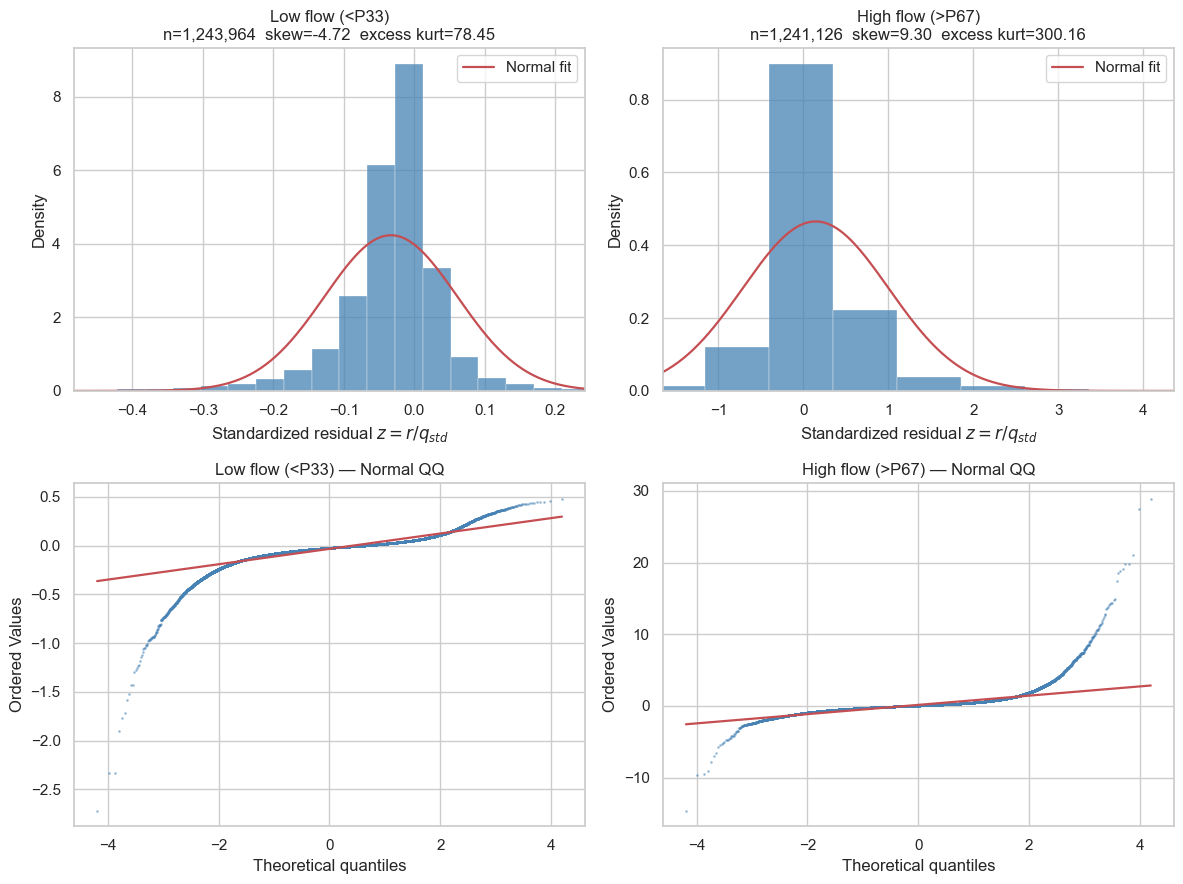

In [8]:
# Cell 10: Residual distributions + Normal QQ, split by flow regime
# Standardize per basin by q_std (per-basin obs SD) -> z = r / q_std, matching the head's
# standardized-NLL target (continue.md s4). Pooling RAW residuals across basins would mix
# scales and fake heavy tails; skew/kurtosis are scale-invariant, so z isolates SHAPE.
q_std = obs_mm.std(axis=0)                              # per-basin obs SD (proxy for q_std)
z = resid.div(q_std, axis=1)
pct = obs_mm.rank(pct=True)                             # within-basin flow percentile

zf, pf = z.values.ravel(), pct.values.ravel()
ok = np.isfinite(zf) & np.isfinite(pf)
zok, pok = zf[ok], pf[ok]
regimes = {'Low flow (<P33)': pok < 0.33, 'High flow (>P67)': pok > 0.67}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for j, (name, sel) in enumerate(regimes.items()):
    d = zok[sel]
    sk, ku = stats.skew(d), stats.kurtosis(d)          # Fisher: excess kurtosis (0 = Normal)

    # Histogram + Normal(mean, std) overlay
    ax = axes[0, j]
    clip = np.quantile(d, [0.005, 0.995])
    sns.histplot(d, bins=120, stat='density', color='steelblue', edgecolor=None, ax=ax)
    xs = np.linspace(*clip, 300)
    ax.plot(xs, stats.norm.pdf(xs, d.mean(), d.std()), 'r-', lw=1.6, label='Normal fit')
    ax.set(xlim=tuple(clip), xlabel='Standardized residual $z = r / q_{std}$',
           title=f'{name}\nn={d.size:,}  skew={sk:.2f}  excess kurt={ku:.2f}')
    ax.legend()

    # Normal QQ (subsample for legibility/speed; departures = skew/heavy tails)
    axq = axes[1, j]
    samp = d if d.size <= 50_000 else RNG.choice(d, 50_000, replace=False)
    stats.probplot(samp, dist='norm', plot=axq)
    axq.get_lines()[0].set(marker='.', ms=2, color='steelblue', alpha=0.4)
    axq.get_lines()[1].set(color='r', lw=1.6)
    axq.set_title(f'{name} — Normal QQ')
plt.tight_layout()
plt.show()


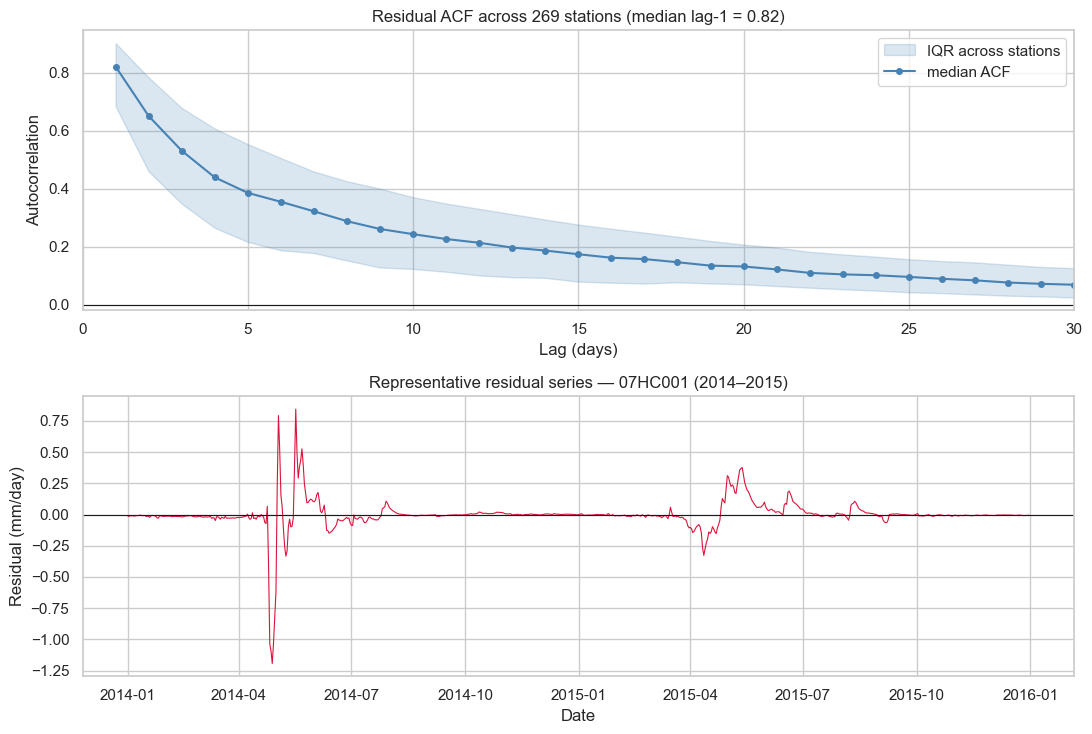

In [9]:
# Cell 11: Residual ACF (across stations) + representative time-series strip
# Per-station ACF (pandas autocorr is NaN-robust pairwise), aggregated across stations.
# Strong lag-1 persistence => residuals are NOT iid; the head's NLL likelihood treats
# them as independent, so effective sample size is inflated (flag for calibration later).
MAX_LAG = 30
lags = np.arange(1, MAX_LAG + 1)
acf_mat = np.full((len(stations), MAX_LAG), np.nan)
for i, s in enumerate(stations):
    series = resid[s]
    if series.notna().sum() < 365:
        continue
    acf_mat[i] = [series.autocorr(lag=int(k)) for k in lags]

acf_med = np.nanmedian(acf_mat, axis=0)
acf_lo, acf_hi = np.nanpercentile(acf_mat, [25, 75], axis=0)
n_ok = int(np.isfinite(acf_mat[:, 0]).sum())

REP = '07HC001'                                        # full obs coverage
strip = resid.loc['2014-01-01':'2015-12-31', REP]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5))
ax1.fill_between(lags, acf_lo, acf_hi, alpha=0.2, color='steelblue',
                 label='IQR across stations')
ax1.plot(lags, acf_med, 'o-', color='steelblue', ms=4, label='median ACF')
ax1.axhline(0, color='k', lw=0.8)
ax1.set(xlim=(0, MAX_LAG), xlabel='Lag (days)', ylabel='Autocorrelation',
        title=f'Residual ACF across {n_ok} stations '
              f'(median lag-1 = {acf_med[0]:.2f})')
ax1.legend()

ax2.plot(strip.index, strip.values, color='crimson', lw=0.8)
ax2.axhline(0, color='k', lw=0.8)
ax2.set(xlabel='Date', ylabel='Residual (mm/day)',
        title=f'Representative residual series — {REP} (2014–2015)')
plt.tight_layout()
plt.show()


## OOD Anchoring and Bridge:

### Event hydrographs for the AR and heat-dome windows - Obs vs $\hat\mu$ with ensemble envelope, residual plotted beneath. 
The mean's baseline behavior and bias at the two extremes, which everything in the variance/OOD stage reference. 

One cell for AR. One cell for Heat Dome.

AR top responders by 2021 anomaly-z -> 08HA016 (z=11.6), 08NL071 (z=10.0), 08LG048 (z=8.6), 08NL038 (z=7.2), 08NL024 (z=6.9)


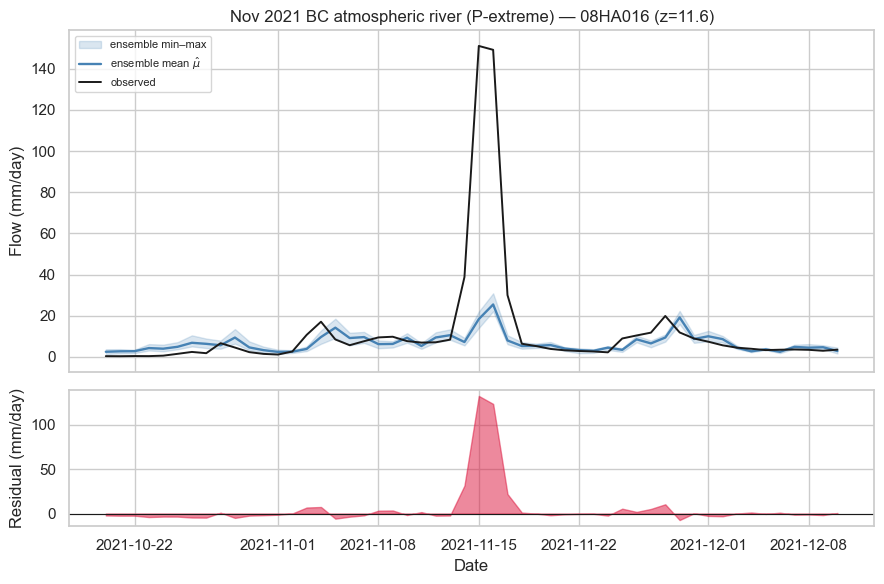

In [10]:
# Cell 13a: OOD anchoring — Nov 2021 BC atmospheric-river flood (P-extreme)
# Data-driven station pick: the basin whose Nov-2021 flow is most anomalous vs Novembers in
# all OTHER years (z-score), among basins with good coverage in the plot window. Where the
# event actually shows up in the data — no geographic assumption. Reuses cell-6 objects.
MONTHS, PLOT = [11], ('2021-10-20', '2021-12-10')
yr, mo = obs_mm.index.year, obs_mm.index.month
sel = np.isin(mo, MONTHS)
wmax = obs_mm[sel].groupby(yr[sel]).max()                      # year x station: window-max obs
others = wmax.drop(index=2021)
z = (wmax.loc[2021] - others.mean()) / others.std()           # 2021 anomaly vs other years
cov = obs_mm.loc[PLOT[0]:PLOT[1]].notna().mean()
cand = z[(cov > 0.6) & np.isfinite(z)].sort_values(ascending=False)
print('AR top responders by 2021 anomaly-z -> '
      + ', '.join(f'{s} (z={cand[s]:.1f})' for s in cand.index[:5]))

s = cand.index[0]                                              # most anomalous responder
a, b = PLOT
o, m = obs_mm.loc[a:b, s], mu.loc[a:b, s]
env = np.stack([d.loc[m.index, s].values for d in _members])   # 10 members x T

fig, (ax, axr) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                              gridspec_kw={'height_ratios': [2.5, 1]})
ax.fill_between(m.index, env.min(0), env.max(0), color='steelblue', alpha=0.20,
                label='ensemble min–max')
ax.plot(m.index, m.values, color='steelblue', lw=1.7, label='ensemble mean $\\hat\\mu$')
ax.plot(o.index, o.values, color='k', lw=1.4, label='observed')
ax.set(ylabel='Flow (mm/day)',
       title=f'Nov 2021 BC atmospheric river (P-extreme) — {s} (z={cand.iloc[0]:.1f})')
ax.legend(loc='upper left', fontsize=8)

r = o - m
axr.fill_between(r.index, r.values, 0, color='crimson', alpha=0.5)
axr.axhline(0, color='k', lw=0.8)
axr.set(ylabel='Residual (mm/day)', xlabel='Date')
plt.tight_layout()
plt.show()


Heat-dome top responders by 2021 anomaly-z -> 08EG012 (z=8.4), 08FF003 (z=5.3), 08FF001 (z=5.1), 08FF002 (z=5.1), 07OA001 (z=3.6)


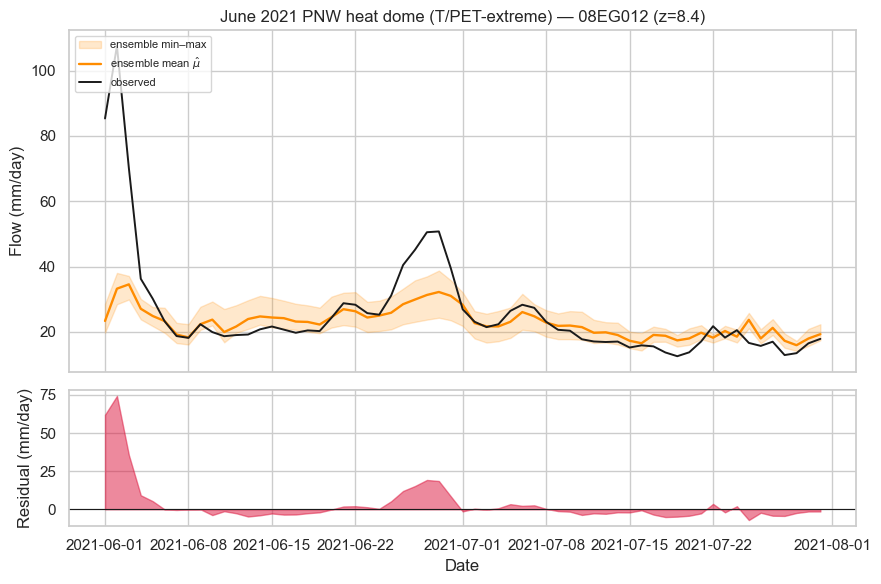

In [11]:
# Cell 13b: OOD anchoring — June 2021 PNW heat dome (T/PET-extreme)
# Same data-driven pick, June–July window (the melt / ET response season). Reuses cell-6 objects.
MONTHS, PLOT = [6, 7], ('2021-06-01', '2021-07-31')
yr, mo = obs_mm.index.year, obs_mm.index.month
sel = np.isin(mo, MONTHS)
wmax = obs_mm[sel].groupby(yr[sel]).max()                      # year x station: window-max obs
others = wmax.drop(index=2021)
z = (wmax.loc[2021] - others.mean()) / others.std()           # 2021 anomaly vs other years
cov = obs_mm.loc[PLOT[0]:PLOT[1]].notna().mean()
cand = z[(cov > 0.6) & np.isfinite(z)].sort_values(ascending=False)
print('Heat-dome top responders by 2021 anomaly-z -> '
      + ', '.join(f'{s} (z={cand[s]:.1f})' for s in cand.index[:5]))

s = cand.index[0]                                              # most anomalous responder
a, b = PLOT
o, m = obs_mm.loc[a:b, s], mu.loc[a:b, s]
env = np.stack([d.loc[m.index, s].values for d in _members])   # 10 members x T

fig, (ax, axr) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                              gridspec_kw={'height_ratios': [2.5, 1]})
ax.fill_between(m.index, env.min(0), env.max(0), color='darkorange', alpha=0.20,
                label='ensemble min–max')
ax.plot(m.index, m.values, color='darkorange', lw=1.7, label='ensemble mean $\\hat\\mu$')
ax.plot(o.index, o.values, color='k', lw=1.4, label='observed')
ax.set(ylabel='Flow (mm/day)',
       title=f'June 2021 PNW heat dome (T/PET-extreme) — {s} (z={cand.iloc[0]:.1f})')
ax.legend(loc='upper left', fontsize=8)

r = o - m
axr.fill_between(r.index, r.values, 0, color='crimson', alpha=0.5)
axr.axhline(0, color='k', lw=0.8)
axr.set(ylabel='Residual (mm/day)', xlabel='Date')
plt.tight_layout()
plt.show()


AR flood (P, Nov): n=49, shrinkage slope=0.16, 80% of obs peaks above the full ensemble, median mu/obs peak=0.39
Heat dome (T/PET, Jun–Jul): n=55, shrinkage slope=0.30, 58% of obs peaks above the full ensemble, median mu/obs peak=0.79


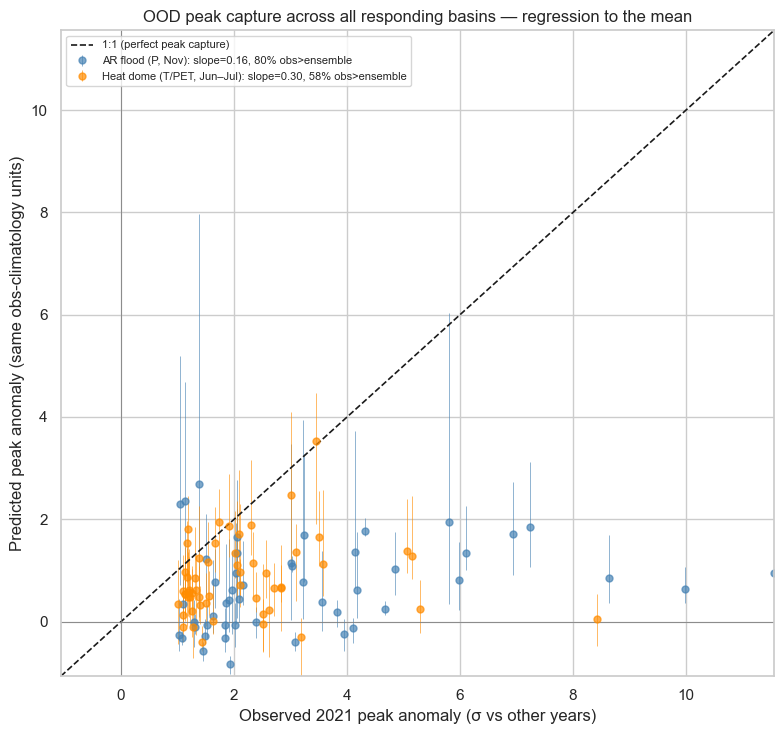

In [12]:
# Cell 13c: OOD peak capture across ALL responding basins (generalizes 13a/13b)
# Single-station hydrographs are anecdotes; this pools every basin that responded to each
# event. For each responder, compare the 2021 event-window PEAK to its climatology in the
# SAME calendar window across other years, standardized by that basin's own obs climatology
# so basins of different scale are comparable.
#   x = observed peak anomaly (sigma vs other years)
#   y = ensemble-mean peak anomaly, in the SAME obs-climatology units
#   error bar = 10-member ensemble min-max (epistemic envelope) at the peak
# Slope-through-origin < 1 = regression to the mean (the model predicts only a fraction of
# the anomaly). "% obs above ensemble" = confidently-wrong rate (D-blind: the ensemble does
# not even bracket the truth). Reuses obs_mm, mu, _members, dates, stations from cell 6.
EVENTS = {
    'AR flood (P, Nov)':          {'months': [11],    'color': 'steelblue'},
    'Heat dome (T/PET, Jun–Jul)': {'months': [6, 7],  'color': 'darkorange'},
}
Z_RESPOND = 1.0                                   # responder = 2021 obs peak > 1 sigma above normal
yr, mo = obs_mm.index.year, obs_mm.index.month

fig, ax = plt.subplots(figsize=(8, 7.5))
hi_lim, lo_lim = 0, 0
for name, cfg in EVENTS.items():
    sel = np.isin(mo, cfg['months']); yrs = yr[sel]
    obs_wm = obs_mm[sel].groupby(yrs).max()                    # year x station: window-max
    mu_wm  = mu[sel].groupby(yrs).max()
    mem_wm = [d.loc[dates, stations][sel].groupby(yrs).max() for d in _members]
    cm, cs = obs_wm.drop(index=2021).mean(), obs_wm.drop(index=2021).std()
    oa = (obs_wm.loc[2021] - cm) / cs                          # observed peak anomaly
    pa = (mu_wm.loc[2021]  - cm) / cs                          # predicted peak anomaly (obs units)
    mem2021 = np.stack([m.loc[2021] for m in mem_wm])          # 10 x stations
    elo = pd.Series((mem2021.min(0) - cm) / cs, index=obs_wm.columns)
    ehi = pd.Series((mem2021.max(0) - cm) / cs, index=obs_wm.columns)

    g = (oa > Z_RESPOND) & np.isfinite(pa) & np.isfinite(cs) & (cs > 0)
    x, y = oa[g].values, pa[g].values
    ylo, yhi = elo[g].values, ehi[g].values
    slope = np.sum(x * y) / np.sum(x * x)                      # shrinkage through origin
    cw = np.mean(x > yhi)                                      # obs above entire ensemble
    print(f'{name}: n={int(g.sum())}, shrinkage slope={slope:.2f}, '
          f'{cw:.0%} of obs peaks above the full ensemble, '
          f'median mu/obs peak={np.median((mu_wm.loc[2021][g]/obs_wm.loc[2021][g]).values):.2f}')

    ax.errorbar(x, y, yerr=[np.clip(y - ylo, 0, None), np.clip(yhi - y, 0, None)],
                fmt='o', ms=5, color=cfg['color'], alpha=0.7, ecolor=cfg['color'],
                elinewidth=0.6, capsize=0,
                label=f'{name}: slope={slope:.2f}, {cw:.0%} obs>ensemble')
    hi_lim = max(hi_lim, np.nanmax(x), np.nanmax(yhi)); lo_lim = min(lo_lim, np.nanmin(ylo))

ax.plot([lo_lim, hi_lim], [lo_lim, hi_lim], 'k--', lw=1.2, label='1:1 (perfect peak capture)')
ax.axhline(0, color='grey', lw=0.6); ax.axvline(0, color='grey', lw=0.6)
ax.set(xlim=(lo_lim, hi_lim), ylim=(lo_lim, hi_lim),
       xlabel='Observed 2021 peak anomaly (σ vs other years)',
       ylabel='Predicted peak anomaly (same obs-climatology units)',
       title='OOD peak capture across all responding basins — regression to the mean')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


AR flood (P, Nov): forcing-selected n=72/269, shrinkage slope=0.18, 36% obs above full ensemble, median mu/obs peak=0.81
Heat dome (T/PET, Jun–Jul): forcing-selected n=264/269, shrinkage slope=0.38, 36% obs above full ensemble, median mu/obs peak=0.88


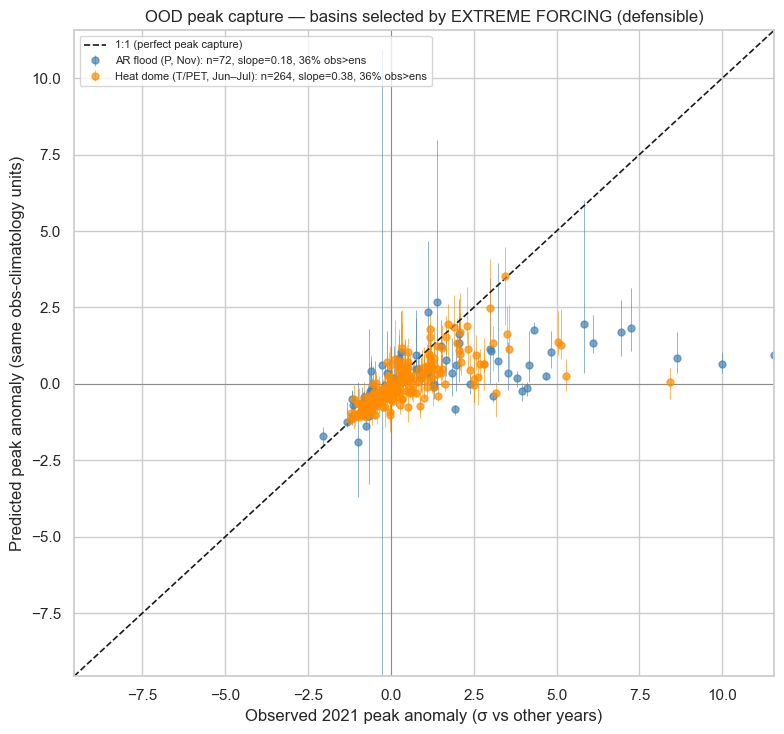

In [13]:
# Cell 13d: OOD peak capture, FORCING-based selection (removes 13c's selection bias)
# 13c selected basins by extreme OBSERVED flow, then assessed flow prediction -> conditioning
# on the outcome builds in regression-to-the-mean. Here selection is on the INPUT the model was
# fed: basins whose 2021 event-window FORCING (Nov precip / Jun–Jul Tmax) was extreme vs other
# years. Selecting on inputs and measuring output error is NOT circular -> the shrinkage slope
# is a defensible effect size: "given OOD-extreme forcing, how much of the response does the
# model produce?" Residual caveat: obs noise on the x-axis still attenuates the slope slightly
# (errors-in-variables), but that is small and not the conditioning bias 13c carried.
CLIM = PROCESSED_DATA_DIR / 'climate'
precip = pd.read_csv(CLIM / 'daily_precipitation.csv', index_col=0,
                     parse_dates=True).reindex(index=dates, columns=stations)
tmax = pd.read_csv(CLIM / 'daily_temp_max.csv', index_col=0,
                   parse_dates=True).reindex(index=dates, columns=stations)
EVENTS = {
    'AR flood (P, Nov)':          {'months': [11],   'forcing': precip, 'color': 'steelblue'},
    'Heat dome (T/PET, Jun–Jul)': {'months': [6, 7], 'forcing': tmax,   'color': 'darkorange'},
}
Z_FORCE = 1.5                                     # selection: 2021 forcing peak > 1.5 sigma (INPUT was OOD)
yr, mo = obs_mm.index.year, obs_mm.index.month

fig, ax = plt.subplots(figsize=(8, 7.5))
hi_lim, lo_lim = 0, 0
for name, cfg in EVENTS.items():
    sel = np.isin(mo, cfg['months']); yrs = yr[sel]
    fwm = cfg['forcing'][sel].groupby(yrs).max()                       # forcing window-max
    fa = (fwm.loc[2021] - fwm.drop(index=2021).mean()) / fwm.drop(index=2021).std()  # SELECTOR (input)
    owm = obs_mm[sel].groupby(yrs).max(); mwm = mu[sel].groupby(yrs).max()
    mem = [d.loc[dates, stations][sel].groupby(yrs).max() for d in _members]
    cm, cs = owm.drop(index=2021).mean(), owm.drop(index=2021).std()
    oa = (owm.loc[2021] - cm) / cs                                     # observed peak anomaly (x)
    pa = (mwm.loc[2021] - cm) / cs                                     # predicted peak anomaly (y)
    m21 = np.stack([m.loc[2021] for m in mem])
    elo = pd.Series((m21.min(0) - cm) / cs, index=owm.columns)
    ehi = pd.Series((m21.max(0) - cm) / cs, index=owm.columns)

    g = (fa > Z_FORCE) & np.isfinite(pa) & np.isfinite(oa) & (cs > 0)  # SELECT ON FORCING, not obs
    x, y = oa[g].values, pa[g].values
    ylo, yhi = elo[g].values, ehi[g].values
    slope = np.sum(x * y) / np.sum(x * x)
    cw = np.mean(x > yhi)
    print(f'{name}: forcing-selected n={int(g.sum())}/{len(stations)}, shrinkage slope={slope:.2f}, '
          f'{cw:.0%} obs above full ensemble, '
          f'median mu/obs peak={np.median((mwm.loc[2021][g] / owm.loc[2021][g]).values):.2f}')

    ax.errorbar(x, y, yerr=[np.clip(y - ylo, 0, None), np.clip(yhi - y, 0, None)],
                fmt='o', ms=5, color=cfg['color'], alpha=0.7, ecolor=cfg['color'],
                elinewidth=0.6, capsize=0,
                label=f'{name}: n={int(g.sum())}, slope={slope:.2f}, {cw:.0%} obs>ens')
    hi_lim = max(hi_lim, np.nanmax(x), np.nanmax(yhi)); lo_lim = min(lo_lim, np.nanmin(ylo))

ax.plot([lo_lim, hi_lim], [lo_lim, hi_lim], 'k--', lw=1.2, label='1:1 (perfect peak capture)')
ax.axhline(0, color='grey', lw=0.6); ax.axvline(0, color='grey', lw=0.6)
ax.set(xlim=(lo_lim, hi_lim), ylim=(lo_lim, hi_lim),
       xlabel='Observed 2021 peak anomaly (σ vs other years)',
       ylabel='Predicted peak anomaly (same obs-climatology units)',
       title='OOD peak capture — basins selected by EXTREME FORCING (defensible)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


Jumping off from here is its own methodology requiring Hydrological Lit. This is too complex to frame for MVE. See EXP6.

## Part 2 - Variance Foundations

Notes about this analysis:

We split the spread around $\hat\mu$ into epistemic (between-member, from the 10 frozen members) and aleatoric (the remainder $\hat\sigma$ will model), identify the structure that remainder takes, and locate it where it matters: tails and the two events. 

Everything is conditioned on the Part 1 bias so $\text{bias}^2$ doesn't leak into the aleatoric term, and carries bootstrap CIs since the remainder is a noisy difference of variances.



## From model analysis to ensemble analysis (interpretive preamble)

Part 1 studied **one** fitted function and asked *where it errs* (residual $r_t = y_t - \hat\mu_t$). Part 2 studies the **spread across** the $M$ members and asks *where the model is unsure*. The arithmetic — LTV, the $T-E/M$ remainder, the $\sigma_e^2$ vs $\sigma_e^2/M$ subtraction — is in the math cell above. This preamble is what the arithmetic does **not** tell you: what the spread $\hat\sigma_e^2$ actually *means*, and what it licenses us to claim.

**1. What generates the spread.** The members share architecture, features, and training data; they differ only in random initialization $\theta_m^{(0)}$ and SGD / mini-batch noise. Each $f_m = f(\,\cdot\,;\theta_m)$ is a different mode that gradient descent fell into, so $\{\theta_m\}_{m=1}^{M}$ is a crude, **uncalibrated** sample from a posterior over functions $p(\theta \mid \mathcal{D})$ — *not* a Bayesian one. It functions as uncertainty only because the basins converge where data constrains the fit and diverge where it does not:

$$
\hat\sigma_e^2(x) = \tfrac{1}{M-1}\textstyle\sum_m \big(f_m(x)-\hat\mu(x)\big)^2 \ \text{ large} \iff \text{data did not pin } f \text{ at } x.
$$

**2. Why $\hat\sigma_e^2 \approx$ epistemic — and the weight of that "$\approx$".** Epistemic = *reducible* uncertainty (more data / a better model shrinks it); the ensemble sees it because disagreement tracks data sparsity. But everything the members **share** is invisible to the spread — shared architecture, shared training data, shared forcing. Correlated errors produce **no spread**, so

$$
\hat\sigma_e^2(x) \ \le\ \sigma_e^2(x) \qquad \text{(systematically, and worst at the extremes).}
$$

$\hat\sigma_e^2$ is therefore a **lower bound** on epistemic uncertainty — the D-blind mechanism in one line: where all members extrapolate the same wrong way, they agree, and the spread under-reports.

**3. Why only the epistemic term is free.** From LTV,

$$
\mathrm{Var}(y\mid x)=\underbrace{\mathbb{E}_\theta\!\big[\mathrm{Var}(y\mid x,\theta)\big]}_{\sigma_a^2}+\underbrace{\mathrm{Var}_\theta\!\big[\mathbb{E}(y\mid x,\theta)\big]}_{\sigma_e^2}.
$$

Point-predicting members emit a **mean only**, so the per-member term $\mathrm{Var}(y\mid x,\theta_m)$ is empty: the ensemble hands you $\sigma_e^2$ pointwise, but $\sigma_a^2$ must be **backed out** of pooled residuals ($\hat\sigma_a^2 = T - \sigma_e^2/M$, cell 18). *This is the argument for the variance head* — to make each member report its own $\mathrm{Var}(y\mid x,\theta_m)$ instead of inferring the larger term by subtraction.

**4. Agreement is ambiguous (the central trap).** When the epistemic *share* collapses toward high flow, a small $\hat\sigma_e^2$ has two indistinguishable causes:

$$
\hat\sigma_e^2(x)\downarrow \ \Longrightarrow\
\begin{cases}
\text{(a) genuinely low epistemic uncertainty, } & \text{data pinned } f \text{ here; or}\\[2pt]
\text{(b) shared overconfidence, } & \text{members wrong } \textit{together}.
\end{cases}
$$

Between-member variance **cannot** separate (a) from (b). Disagreement is sufficient evidence of uncertainty; **agreement is not evidence of confidence.** So "epistemic share $\approx 0.02$ at high flow" reads as *"the members are correlated here, cause unknown"* — never *"the model is sure."*

**5. Calibration is the only bridge.** Resolving (a) vs (b) is not an ensemble-internal operation; it needs an external check against $y$ — do $\approx q$ of observations fall inside the $q$-interval, stratified by regime? Where the intervals under-cover the tail, case (b) is caught. This is **Claim 1** (OOD/tail calibration), and predictive intervals degrade exactly under distribution shift (Ovadia et al. 2019) — which is *why* tail-aware UQ (the Student-$t$ / Bayesian fork) is needed rather than assumed.

**One line.** A single model tells you where it is *wrong*; an ensemble tells you where it is *unsure* — but only where the members had reason to disagree, and never where they are wrong together. Part 2 (cells 17–19) **measures the disagreement**; the OOD calibration step **decides whether the agreement was earned**.

*Resources to read on this:* 
Lakshminarayanan et al. 2017 (deep ensembles + variance head = this method); 
Fort et al. 2019 (what the spread samples, layer 1); 
Hüllermeier & Waegeman 2021 (aleatoric/epistemic at depth, layers 2–4); 
Ovadia et al. 2019 (calibration under shift, layer 5); 
Klotz et al. 2022 / Beven & Binley 1992 (the hydrology UQ lineage this sits in).

## Decomposition: epistemic vs aleatoric

### Between-member variance (epistemic): per-timestep spread of the 10 members
Var across the frozen members at each x — the model uncertainty read straight from the ensemble, no head needed.

### Total vs epistemic: smoothed $(y - \hat\mu)^2$ against between-member variance
Total residual variance = epistemic + aleatoric remainder; the remainder is the head's target and budget. Subtract the Part 1 conditional bias first (smooth with WINDOW, WINDOWS_ROBUST for sensitivity).

### Variance partition by flow percentile: stacked epistemic/aleatoric shares per bin, bootstrap CIs
Mirrors the Part 1 binned-bias figure — which component dominates per regime, and where the remainder is too small to read.

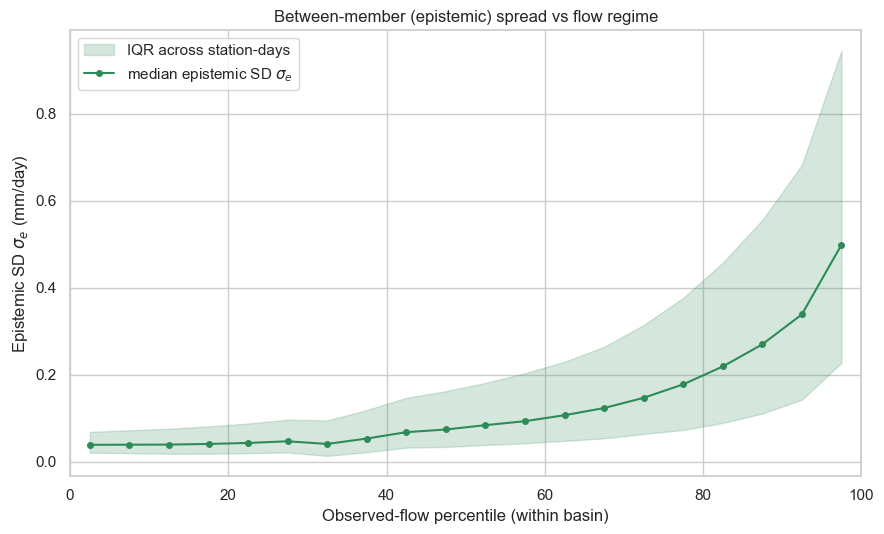

epistemic sigma_e (mm/day): overall median 0.082, low-flow bin 0.039, high-flow bin 0.499


In [14]:
# Cell 17: Between-member (epistemic) variance — sigma_e^2(x_t), pointwise + by flow regime
# sigma_e^2 = (1/(M-1)) sum_m (f_m - mu_hat)^2, available at EVERY (station,day) from the 10
# frozen members (math cell). No head needed. Establishes `epi` + shared flat arrays for 18-19.
stack = np.stack([d.loc[dates, stations].values for d in _members])   # (M, T, S)
epi = pd.DataFrame(stack.var(axis=0, ddof=1), index=dates, columns=stations)   # sigma_e^2 (M-1)

# Shared flat arrays for Part 2 — within-basin obs-flow percentile (consistent with cells 7/10)
pct2     = obs_mm.rank(pct=True)
r_flat   = resid.values.ravel()
r2_flat  = r_flat ** 2
epi_flat = epi.values.ravel()
pp_flat  = pct2.values.ravel()
v2 = np.isfinite(r_flat) & np.isfinite(epi_flat) & np.isfinite(pp_flat)

# Binned epistemic SD (sqrt) by flow percentile — median + IQR across station-days
NB = 20
b = np.clip((pp_flat[v2] * NB).astype(int), 0, NB - 1)
ctr = (np.arange(NB) + 0.5) / NB * 100
se = np.sqrt(epi_flat[v2])                                  # epistemic SD (mm/day)
med = np.array([np.median(se[b == k]) for k in range(NB)])
q1  = np.array([np.percentile(se[b == k], 25) for k in range(NB)])
q3  = np.array([np.percentile(se[b == k], 75) for k in range(NB)])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.fill_between(ctr, q1, q3, alpha=0.2, color='seagreen', label='IQR across station-days')
ax.plot(ctr, med, 'o-', color='seagreen', ms=4, label='median epistemic SD $\\sigma_e$')
ax.set(xlabel='Observed-flow percentile (within basin)', ylabel='Epistemic SD $\\sigma_e$ (mm/day)',
       xlim=(0, 100), title='Between-member (epistemic) spread vs flow regime')
ax.legend()
plt.tight_layout()
plt.show()
print(f'epistemic sigma_e (mm/day): overall median {np.median(se):.3f}, '
      f'low-flow bin {med[0]:.3f}, high-flow bin {med[-1]:.3f}')


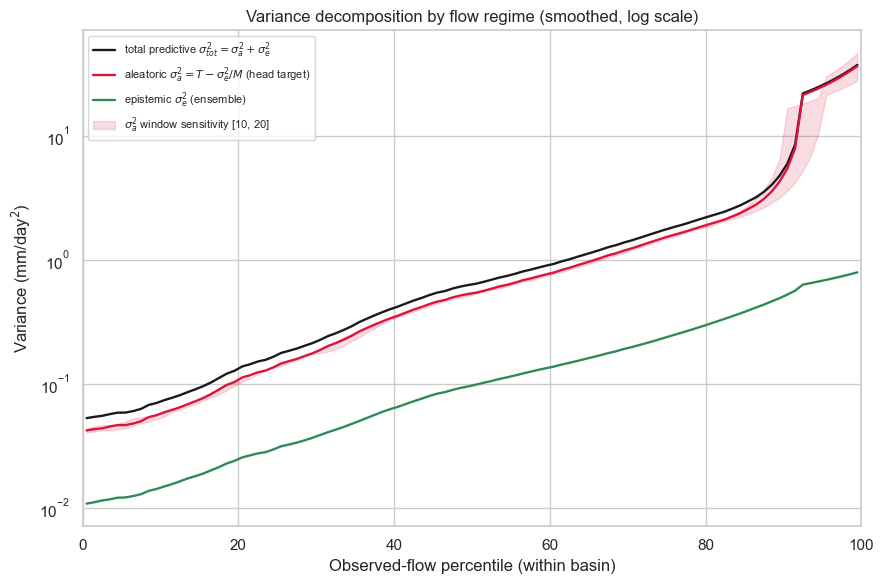

epistemic share of total predictive var sigma_e^2/(sigma_a^2+sigma_e^2): low-flow 0.20, high-flow 0.02  (aleatoric dominates, esp. at high flow)


In [15]:
# Cell 18: Residual variance vs epistemic -> aleatoric remainder, by flow percentile
# Per bin (corrected 1/M accounting, see math cell notes 1-2):
#   residual var about the mean   T(x) = MSR - b^2 = Var(r|x) = sigma_a^2 + sigma_e^2/M
#   epistemic (between-member)    E(x) = mean sigma_e^2
#   aleatoric (head target)       A(x) = T(x) - E(x)/M     <-- subtract sigma_e^2/M, NOT full sigma_e^2
#   total predictive (reported)   V(x) = A(x) + E(x)       = T(x) + (M-1)/M * E(x)
# Why /M: the ensemble MEAN averages out ~(M-1)/M of the between-member spread, so the residual
# about mu_hat already contains only sigma_e^2/M of epistemic. Subtracting the full sigma_e^2 would
# over-subtract by (M-1)/M * sigma_e^2. Members are positively correlated so true Var(mu_hat) in
# [sigma_e^2/M, sigma_e^2]; A=T-E/M is the conservative (largest-aleatoric) edge -> A is an upper
# bound on the head target, A=T-E the lower edge (the two bracket it).
M = N_MEMBERS
FB = 100
bb = np.clip((pp_flat[v2] * FB).astype(int), 0, FB - 1)
ctrf = (np.arange(FB) + 0.5) / FB * 100
msr  = np.array([r2_flat[v2][bb == k].mean()  for k in range(FB)])
bias = np.array([r_flat[v2][bb == k].mean()   for k in range(FB)])
epb  = np.array([epi_flat[v2][bb == k].mean() for k in range(FB)])

smooth = lambda a, w: pd.Series(a).rolling(w, center=True, min_periods=1).mean().values
T = smooth(msr, WINDOW) - smooth(bias, WINDOW) ** 2        # residual var about mean = sigma_a^2 + sigma_e^2/M
E = smooth(epb, WINDOW)                                    # epistemic sigma_e^2
A = np.clip(T - E / M, 0, None)                            # aleatoric remainder (head target)
V = A + E                                                  # total predictive variance (full epistemic restored)
# bias^2 is subtracted into T but intentionally NOT plotted: on a log axis it dives toward
# -inf where the signed bias crosses zero (~83rd pct), a scale artifact, not a variance
# feature. The bias structure and its zero-crossing are in Cell 7 (signed mean residual).
A_rob = [np.clip((smooth(msr, w) - smooth(bias, w) ** 2) - smooth(epb, w) / M, 0, None)
         for w in WINDOWS_ROBUST]                          # remainder sensitivity to smoothing

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(ctrf, V, color='k', lw=1.7, label='total predictive $\\sigma^2_{tot}=\\sigma_a^2+\\sigma_e^2$')
ax.plot(ctrf, A, color='crimson', lw=1.7, label='aleatoric $\\sigma_a^2=T-\\sigma_e^2/M$ (head target)')
ax.plot(ctrf, E, color='seagreen', lw=1.7, label='epistemic $\\sigma_e^2$ (ensemble)')
ax.fill_between(ctrf, np.min(A_rob, 0), np.max(A_rob, 0), color='crimson', alpha=0.15,
                label=f'$\\sigma_a^2$ window sensitivity {WINDOWS_ROBUST}')
ax.set(xlabel='Observed-flow percentile (within basin)', ylabel='Variance (mm/day$^2$)',
       yscale='log', xlim=(0, 100),
       title='Variance decomposition by flow regime (smoothed, log scale)')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()
print(f'epistemic share of total predictive var sigma_e^2/(sigma_a^2+sigma_e^2): '
      f'low-flow {E[0] / V[0]:.2f}, high-flow {E[-1] / V[-1]:.2f}  '
      f'(aleatoric dominates, esp. at high flow)')


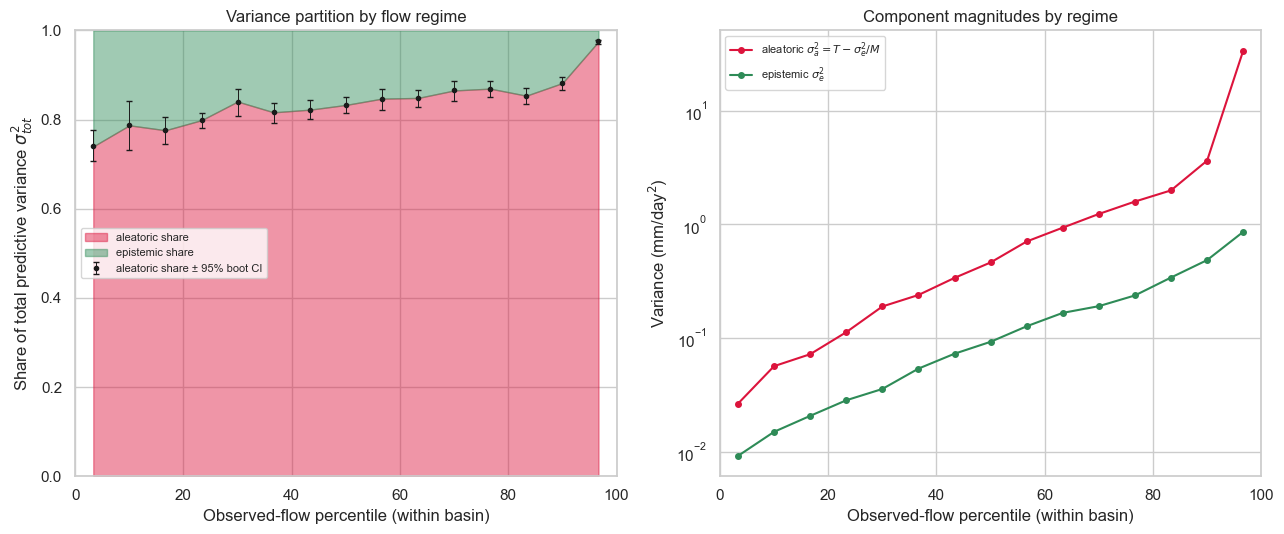

aleatoric share of total predictive var: low-flow bin 0.74 [0.71,0.78], high-flow bin 0.98 [0.97,0.98]


In [16]:
# Cell 19: Variance partition by flow percentile — aleatoric vs epistemic shares, bootstrap CIs
# Per bin (corrected 1/M accounting, math cell notes 1-2): T = MSR - b^2 = sigma_a^2 + sigma_e^2/M,
#   E = mean sigma_e^2, A = max(T - E/M, 0) = aleatoric, V = A + E = total predictive variance.
# Shares are of the TOTAL predictive variance V (the quantity a calibrated interval reports):
#   aleatoric share = A / V ; epistemic share = E / V  (sum to 1). Bootstrap over station-days in
#   each bin for a 95% CI on the aleatoric share (vectorized; per-bin sample capped for speed).
# CAVEAT: iid bootstrap; residuals are autocorrelated + spatially correlated -> effective n << n,
# so these CIs are anti-conservative. Block/regional resampling is the honest fix (deferred, per
# the 2026-06-03 methods note); read widths as indicative.
M = N_MEMBERS
NBP = 15
bi = np.clip((pp_flat[v2] * NBP).astype(int), 0, NBP - 1)
ctrp = (np.arange(NBP) + 0.5) / NBP * 100
R2, R, EP = r2_flat[v2], r_flat[v2], epi_flat[v2]
CAP = 8000                                              # per-bin bootstrap cap (wider CI = conservative)

sh_med, sh_lo, sh_hi, ale_mag, epi_mag = [], [], [], [], []
for k in range(NBP):
    idx = np.where(bi == k)[0]
    use = idx if idx.size <= CAP else RNG.choice(idx, CAP, replace=False)
    R2u, Ru, EPu = R2[use], R[use], EP[use]
    Tk = R2u.mean() - Ru.mean() ** 2; Ek = EPu.mean()
    Ak = max(Tk - Ek / M, 0.0)                                       # aleatoric (subtract sigma_e^2/M)
    ale_mag.append(Ak); epi_mag.append(Ek)
    bm = RNG.integers(0, use.size, size=(N_BOOTSTRAP, use.size))     # vectorized resample
    Tb = R2u[bm].mean(1) - Ru[bm].mean(1) ** 2
    Eb = EPu[bm].mean(1)
    Ab = np.clip(Tb - Eb / M, 0, None)
    Vb = Ab + Eb                                                     # total predictive variance
    sh = np.where(Vb > 0, Ab / Vb, np.nan)                          # aleatoric share of V
    sh_med.append(np.nanmedian(sh)); sh_lo.append(np.nanpercentile(sh, 2.5)); sh_hi.append(np.nanpercentile(sh, 97.5))
sh_med, sh_lo, sh_hi = map(np.asarray, (sh_med, sh_lo, sh_hi))
ale_mag, epi_mag = np.asarray(ale_mag), np.asarray(epi_mag)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5.5))
# stacked shares (aleatoric below, epistemic above) + bootstrap CI on the boundary
axA.fill_between(ctrp, 0, sh_med, color='crimson', alpha=0.45, label='aleatoric share')
axA.fill_between(ctrp, sh_med, 1, color='seagreen', alpha=0.45, label='epistemic share')
axA.errorbar(ctrp, sh_med, yerr=[sh_med - sh_lo, sh_hi - sh_med], fmt='o', ms=3,
             ecolor='k', elinewidth=0.7, capsize=2, color='k', label='aleatoric share ± 95% boot CI')
axA.set(xlim=(0, 100), ylim=(0, 1), xlabel='Observed-flow percentile (within basin)',
        ylabel='Share of total predictive variance $\\sigma^2_{tot}$', title='Variance partition by flow regime')
axA.legend(loc='center left', fontsize=8)
# absolute magnitudes (log — they span orders of magnitude)
axB.plot(ctrp, ale_mag, 'o-', color='crimson', ms=4, label='aleatoric $\\sigma_a^2 = T-\\sigma_e^2/M$')
axB.plot(ctrp, epi_mag, 'o-', color='seagreen', ms=4, label='epistemic $\\sigma_e^2$')
axB.set(xlim=(0, 100), yscale='log', xlabel='Observed-flow percentile (within basin)',
        ylabel='Variance (mm/day$^2$)', title='Component magnitudes by regime')
axB.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'aleatoric share of total predictive var: low-flow bin {sh_med[0]:.2f} [{sh_lo[0]:.2f},{sh_hi[0]:.2f}], '
      f'high-flow bin {sh_med[-1]:.2f} [{sh_lo[-1]:.2f},{sh_hi[-1]:.2f}]')


## something else to do with the VE head

Resources:

Nix, D. A., and A. S. Weigend. ‘Estimating the Mean and Variance of the Target Probability Distribution’. Proceedings of 1994 IEEE International Conference on Neural Networks (ICNN’94), vol. 1, 1994, pp. 55–60 vol.1. IEEE Xplore, https://doi.org/10.1109/ICNN.1994.374138.

Pourkamali-Anaraki, Farhad. ‘Probabilistic Neural Networks (PNNs) with t-Distributed Outputs: Adaptive Prediction Intervals Beyond Gaussian Assumptions’. Version 1, arXiv:2503.12354, arXiv, 16 Mar. 2025. arXiv.org, https://doi.org/10.48550/arXiv.2503.12354.

Sluijterman, Laurens, et al. ‘Optimal Training of Mean Variance Estimation Neural Networks’. Neurocomputing, vol. 597, Sept. 2024, p. 127929. DOI.org (Crossref), https://doi.org/10.1016/j.neucom.2024.127929.

Stirn, Andrew, et al. ‘Faithful Heteroscedastic Regression with Neural Networks’. Proceedings of The 26th International Conference on Artificial Intelligence and Statistics, 2023, pp. 5593–613. proceedings.mlr.press, https://proceedings.mlr.press/v206/stirn23a.html.

